## Deontological Lost Insulin experiment

This notebook measures policy outcomes and runtime growth for combinations of utility, legality, and necessity theories over horizons 3–11.

Recommended execution order:

1. Import helpers and define configurations.
2. Build the concrete **configs** list and initialise **er**.
3. Generate planner outputs, or reuse existing outputs, then extract them.
4. Create cleaned and aggregated DataFrames.
5. Export tables and generate outcome/runtime plots.


In [33]:
from scripts.AbstractExperiments import ExperimentRunner
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

def latex_config_name(name):
    return "$" + name.replace("^0", "^{0}") + "$"

def QuickPlotGraph(df_, configs:list, 
                   independent_var:str, 
                   dependent_var:str, 
                   title:str=None, 
                   ind_label:str=None, 
                   dep_label:str=None, 
                   file_out:str=None, 
                   regression:bool=False, 
                   regression_label:bool=False,
                   fig_size:tuple=(8,6)):
    if ind_label is None:
        ind_label = independent_var
    if dep_label is None:
        dep_label = dependent_var
        
    df_a = df_.copy()
    df_a = df_a[df_a['Config_name'].isin(configs)]
    df_aa = (
        df_a
        .groupby(["Config_name", independent_var], as_index=False)[dependent_var]
        .mean()
        .sort_values(["Config_name", independent_var])
    )

    regression_results = {}
    regression_text = []

    fig, ax = plt.subplots(figsize=fig_size)
    for c, g in df_aa.groupby('Config_name', sort=False):
        x = g[independent_var].to_numpy(dtype=float)
        y = g[dependent_var].to_numpy(dtype=float)
        ax.scatter(x, y, alpha=0.75, label=latex_config_name(c))
        observed_line, = ax.plot(x, y, alpha=0.75)

        if regression:
            # log(y) is only defined for strictly positive y values.
            valid = (np.isfinite(x) & np.isfinite(y) & (y > 0))
            x_valid = x[valid]
            y_valid = y[valid]
            
            log_y = np.log(y_valid)

            # log(y) = intercept + growth_rate * x
            growth_rate, intercept = np.polyfit(x_valid, log_y, deg=1)

            scale = np.exp(intercept)

            predicted_log_y = (intercept + growth_rate * x_valid)

            residual_sum_of_squares = np.sum((log_y - predicted_log_y) ** 2)
            total_sum_of_squares = np.sum((log_y - log_y.mean()) ** 2)

            if np.isclose(total_sum_of_squares, 0):
                r_squared = np.nan
            else:
                r_squared = (1 - residual_sum_of_squares / total_sum_of_squares)

            regression_results[c] = { "a": scale, "b": growth_rate, "R_squared": r_squared}

            # Use a dense x range to draw a smooth exponential curve.
            regression_x = np.linspace(x_valid.min(), x_valid.max(), 200,)
            regression_y = scale * np.exp(growth_rate * regression_x) 

            ax.plot(
                regression_x,
                regression_y,
                linestyle="--",
                linewidth=2,
                alpha=0.9,
                color=observed_line.get_color(),
                label='__nolegend__',)
            
            regression_text.append(
                rf"{latex_config_name(c)}: "
                rf"$y={scale:.3g}e^{{{growth_rate:.3g}x}}$, "
                rf"$R^2={r_squared:.4f}$"
            )

    plt.yscale('log')  # Set the y-axis to logarithmic scale
    if (title is None):
        plt.title(f"{ind_label} vs {dep_label}")
    else:
        plt.title(title)

    plt.xlabel(ind_label)
    plt.ylabel(dep_label)

    ax.grid(True, alpha=0.3)
    ax.legend(title="Config", loc='upper left')

    if regression and regression_text and regression_label:
        regression_summary = "\n".join(regression_text)
        # Position the regression summary outside the plotting region.
        ax.text(1.03, 0.98, regression_summary,
            transform=ax.transAxes, va="top", ha="left",
            fontsize=11, linespacing=1.4,
            bbox={"boxstyle": "round,pad=0.5", "facecolor": "white", "edgecolor": "0.7", "alpha": 0.9,},
        )
        # Reserve space on the right for the summary.
        fig.subplots_adjust(right=0.68)
    else:
        fig.tight_layout()

    plt.tight_layout() 
    if (not file_out is None):
        plt.savefig(f"{file_out}/{title}.png")
    plt.show()  # Show the plot
    


## Experiment configurations

**defaultConfig** supplies the default budget and horizon. **inputConfigs** defines the moral theories and considerations for each named configuration, then expands every definition across horizons 3–11.

The next cell converts that mapping into **configs**, the list consumed by **ExperimentRunner**. Each element contains Name, Horizon, Budget, Theories, and Considerations.


In [2]:
defaultConfig = {"Budget": 3, "Horizon": 6}
inputConfigs = {
    "(Hal)^0": {
        "Theories": [["Hal", "Utility", 0]], 
        "Considerations": [["Hal", "Hal"]]
    },
    "(Law)^0, (Hal)^1": {
        "Theories": [["Hal", "Utility", 1], ["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["OrdinalLaw", "OrdinalLaw"]]
    },
    "(Necessity)^0, (Hal)^1": {
        "Theories": [["Hal", "Utility", 1], ["Necessity", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["Necessity", "Necessity"]]
    },
    "(Law)^0, (Hal)^0": {
        "Theories": [["Hal", "Utility", 0], ["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["OrdinalLaw", "OrdinalLaw"]]
    },
    "(Necessity)^0, (Hal)^0": {
        "Theories": [["Hal", "Utility", 0], ["Necessity", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["Necessity", "Necessity"]]
    },
    "(Law)^0, (Necessity)^0, (Hal)^0": {
        "Theories": [["Hal", "Utility", 0], ["Necessity", "Ordinal", 0], ["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["Necessity", "Necessity"], ["OrdinalLaw", "OrdinalLaw"]]
    },
    "(Law)^0, (Necessity)^0, (Hal)^1": {
        "Theories": [["Hal", "Utility", 1], ["Necessity", "Ordinal", 0], ["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["Necessity", "Necessity"], ["OrdinalLaw", "OrdinalLaw"]]
    },
    #"(Law)^0, (Necessity)^0, (Hal)^0, (Carla)^0": {
    #    "Theories": [["Hal", "Utility", 0], ["Necessity", "Ordinal", 0], ["OrdinalLaw", "Ordinal", 0], ["Carla", "Utility", 0]], 
    #    "Considerations": [["Hal", "Hal"], ["Carla", "Carla"], ["Necessity", "Necessity"], ["OrdinalLaw", "OrdinalLaw"]]
    #},
    #"(Law)^1, (Necessity)^1, (Hal)^0, (Carla)^0": {
    #    "Theories": [["Hal", "Utility", 0], ["Necessity", "Ordinal", 1], ["OrdinalLaw", "Ordinal", 1], ["Carla", "Utility", 0]], 
    #    "Considerations": [["Hal", "Hal"], ["Carla", "Carla"], ["Necessity", "Necessity"], ["OrdinalLaw", "OrdinalLaw"]]
    #}
    
}
if True:
    newConfigs = {}
    for i in range(3, 12):
        for key, value in inputConfigs.items():
            newConfigs[f"H={str(i).rjust(3,'0')}_{key}"] = deepcopy(value)
            newConfigs[f"H={str(i).rjust(3,'0')}_{key}"]["Horizon"] = i

    
inputConfigs = newConfigs


In [49]:
configs = []
for name, dat in inputConfigs.items():
    c = deepcopy(defaultConfig)
    c["Name"] = name
    c["Theories"] = dat["Theories"]
    c["Considerations"] = dat["Considerations"]
    c["Budget"] = dat["Budget"] if "Budget" in dat.keys() else c["Budget"]
    c["Horizon"] = dat["Horizon"] if "Horizon" in dat.keys() else c["Horizon"]
    configs.append(c)

## Experiment runner and stored results

**Config_repetitions** and **Environment_repetitions** control repeated runs. **er** manages environment files, raw planner JSON, figures, and TeX output under the DeontologyExp results folder.

The build and planner calls are commented in the extraction cell. Leave them commented to analyse existing files; uncomment them when configurations or planner behaviour change.


In [4]:
Config_repetitions=1
Environment_repetitions=10
er = ExperimentRunner("LostInsulin", configs, MoralPlanner_Location="/../../", outFolder="DeontologyExp")

In [23]:
#er.buildEnvironments(configRepetitions=Config_repetitions)
#er.runPlanner(configRepetitions=Config_repetitions, envRepetitions=Environment_repetitions)
er.extractData(Config_repetitions, Environment_repetitions)

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'Hal', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/DeontologyExp/mdps/H=003_(Hal)^0_con0.json

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'Hal', 'Type': 'Utility', 'Rank': 1}, {'Name': 'OrdinalLaw', 'Type': 'Ordinal', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/DeontologyExp/mdps/H=003_(Law)^0, (Hal)^1_con0.json

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'Hal', 'Type': 'Utility', 'Rank': 1}, {'Name': 'Necessity', 'Type': 'Ordinal', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/DeontologyExp/mdps/H=003_(Necessity)^0, (Hal)^1_con0.json

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'Hal', 'Type': 'Utility', 'Rank': 0}, {'Name': 'OrdinalLaw',

## Clean and aggregate extracted data

The main tables created below are:

| DataFrame | Contents |
|---|---|
| **df** | One row per extracted planner repetition, including configuration, horizon, moral expectations, policy counts, and timing fields |
| **df_** | One row per configuration/horizon after applying **agg_rules**; total time is averaged while deterministic result fields use the first value |

Configuration and ordinal labels are shortened for figures and TeX output. Missing display values become a dash, while numeric plotting columns are converted back to numeric types.


In [ ]:
# Format
agg_rules={"Hal": "first",  "Necessity":'first', "Legality":'first', "Num_of_min_non_accept": 'first', "Num_of_sols": 'first',
                "Min_non_accept": 'first', 'Total_time': 'mean'}

df = pd.DataFrame(er.data)
df = df.replace(["", "N/A", "NA", "nan", "None"], np.nan)
df['Config_name'] = df['Config_name'].str.removesuffix("_Hal_Incr")
df['Config_name'] = df['Config_name'].str[6:]
df = df.round(3)
df = df.replace(np.nan, "-")

df['Config_name'] = df['Config_name'].str.replace("Necessity", "N")
df['Config_name'] = df['Config_name'].str.replace("Hal", "H")
df['Config_name'] = df['Config_name'].str.replace("Carla", "C")
df['Config_name'] = df['Config_name'].str.replace("Law", "L")

df['Hal'] = pd.to_numeric(df['Hal'])
df["Total_time"] = pd.to_numeric(df["Total_time"])


df_ = df.copy()

df_ = df_[["Config_name", "Horizon"] + list(agg_rules.keys())]
df_ = (df.groupby(["Config_name", "Horizon"], as_index=False)
      .agg(agg_rules)
      .sort_values(["Config_name", "Horizon"]))

df_ = df_.replace(np.nan, "-")
df_['Necessity'] = df_['Necessity'].str.replace("R=0", "N/A (0)")
df_['Necessity'] = df_['Necessity'].str.replace("R=-1", "P.D. (-1)")
df_['Necessity'] = df_['Necessity'].str.replace("R=-2", "S.M.R. (-2)")
df_['Necessity'] = df_['Necessity'].str.replace("R=-3", "S.H. (-3)")
df_['Necessity'] = df_['Necessity'].str.replace("R=-4", "C.O. (-4)")
df_['Necessity'] = df_['Necessity'].str.replace("R=-5", "B.N. (-5)")

df_['Legality'] = df_['Legality'].str.replace("R=0", "N.V. (0)")
df_['Legality'] = df_['Legality'].str.replace("R=-1", "O.I. (-1)")
df_['Legality'] = df_['Legality'].str.replace("R=-2", "T (-2)")
df_['Legality'] = df_['Legality'].str.replace("R=-3", "B (-3)")
df_['Legality'] = df_['Legality'].str.replace("R=-4", "R (-4)")
df_['Legality'] = df_['Legality'].str.replace("R=-5", "V.T. (-5)")
df_.head(100)

,Config_name,Horizon,Hal,Necessity,Legality,Num_of_min_non_accept,Num_of_sols,Min_non_accept,Total_time
0,(H)^0,3,-60.6997,-,-,1,1,0.0,105.4
1,(H)^0,4,-58.8442,-,-,1,1,0.0,170.1
2,(H)^0,5,-56.9766,-,-,1,1,0.0,271.0
3,(H)^0,6,-55.2698,-,-,1,1,0.0,312.7
4,(H)^0,7,-53.8968,-,-,1,1,0.0,482.4
...,...,...,...,...,...,...,...,...,...
58,"(N)^0, (H)^1",7,-57.7301,N/A (0),-,1,4,0.0,2005.4
59,"(N)^0, (H)^1",8,-56.3859,N/A (0),-,1,3,0.0,5084.4
60,"(N)^0, (H)^1",9,-55.2831,N/A (0),-,1,3,0.0,6139.5
61,"(N)^0, (H)^1",10,-54.3661,N/A (0),-,1,4,0.0,7717.4


## Result tables

**df_horSix** selects horizon 6 and orders the principal non-Carla configurations for the paper table.

The following cell also splits **df_** by configuration and exports one horizon-growth table per configuration. These cells write TeX files through **SaveDataFrameToTexTemplate**.


In [47]:
non_carlas = ['(H)^0', '(L)^0, (H)^1', '(N)^0, (H)^1', '(L)^0, (H)^0', '(N)^0, (H)^0',
              '(L)^0, (N)^0, (H)^0', '(L)^0, (N)^0, (H)^1']

df_horSix = df_[df_['Config_name'].isin(non_carlas)].copy()

df_horSix['Config_name'] = pd.Categorical(
    df_horSix['Config_name'],
    categories=non_carlas,
    ordered=True
)

df_horSix = (
    df_horSix[df_horSix['Horizon'] == 6]
    .sort_values('Config_name')
    .drop(columns=['Horizon'])
)
SaveDataFrameToTexTemplate(df_horSix, f"{er.texTablesFolder}/LI_LawResults.tex", f"{er.texOutFolder}/_Deon_Policy_table.tex", row_template_mode=True, timestamp=er.datetimeNow)

df_horSix.head(1000)

Successfully saved populated LaTeX to /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/DeontologyExp/tex/_Deon_Policy_table.tex


,Config_name,Hal,Necessity,Legality,Num_of_min_non_accept,Num_of_sols,Min_non_accept,Total_time
3,(H)^0,-55.2698,-,-,1,1,0.000,312.7
21,"(L)^0, (H)^1",-69.3854,-,N.V. (0),1,4,0.000,3162.9
57,"(N)^0, (H)^1",-59.3862,N/A (0),-,1,4,0.000,1522.4
12,"(L)^0, (H)^0",-69.3854,-,N.V. (0),1,4,0.694,3250.0
48,"(N)^0, (H)^0",-55.2698,B.N. (-5),-,1,4,0.386,1488.7
30,"(L)^0, (N)^0, (H)^0",-69.3854,N/A (0),N.V. (0),1,6,0.694,3934.7
39,"(L)^0, (N)^0, (H)^1",-69.3854,N/A (0),N.V. (0),1,6,0.000,3977.3


In [26]:

groups = dict(tuple(df_.groupby("Config_name")))
for conf_name, d in groups.items():
    d = d.drop(columns=['Config_name'])
    SaveDataFrameToTexTemplate(d, f"{er.texTablesFolder}/Horizon_Growth.tex", f"{er.texOutFolder}/{conf_name}_Deon_table.tex", row_template_mode=True, title=conf_name,)
    print(d.to_string())

Successfully saved populated LaTeX to /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/DeontologyExp/tex/(H)^0_Deon_table.tex
   Horizon      Hal Necessity Legality  Num_of_min_non_accept  Num_of_sols  Min_non_accept  Total_time
0        3 -60.6997         -        -                      1            1             0.0       105.4
1        4 -58.8442         -        -                      1            1             0.0       170.1
2        5 -56.9766         -        -                      1            1             0.0       271.0
3        6 -55.2698         -        -                      1            1             0.0       312.7
4        7 -53.8968         -        -                      1            1             0.0       482.4
5        8 -52.7879         -        -                      1            1             0.0       636.3
6        9 -51.8818         -        -                      1            1             0.0       599.5
7    

## Moral outcomes across horizon

These plots use filtered copies named **df_** derived from the repetition-level **df**.

The multi-axis figures compare Hal utility, an ordinal necessity or legality rank, and non-acceptability against horizon. **QuickPlotGraph** averages a requested dependent variable by configuration and horizon; with regression enabled it fits the exponential form \(y = ae^{bx}\) to positive values.


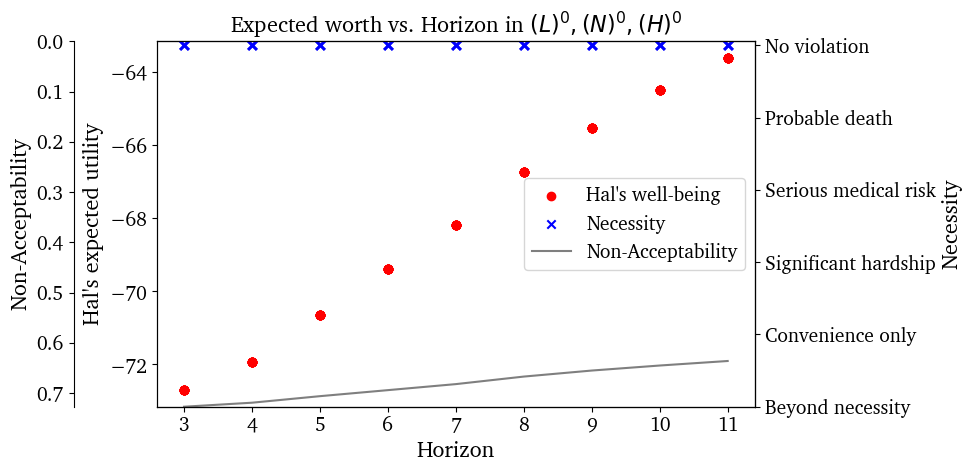

In [27]:
configName = "(L)^0, (N)^0, (H)^0"
dep_var = "Hal"
ord_con_label = "Necessity"
ordinalLabels = {0: "No violation", -1: "Probable death", -2: "Serious medical risk", -3: "Significant hardship", -4: "Convenience only", -5: "Beyond necessity"}

df_ = df.copy()
df_ = df_[df_['Config_name'] == configName].copy()

# 1. FIX UNEVEN SPACING: Force the data to be numeric
df_[dep_var] = pd.to_numeric(df_[dep_var])
df_[ord_con_label] = df_[ord_con_label].str[2:]
df_[ord_con_label] = pd.to_numeric(df_[ord_con_label])
df_['Horizon'] = pd.to_numeric(df_['Horizon'])

fig, ax1 = plt.subplots(figsize=(10, 5))
plt.title(f"Expected worth vs. Horizon in {latex_config_name(configName)}")

# 2. FIX THE LEGEND: Add label="Hal's wellbeing"
ax1.scatter(df_['Horizon'], df_[dep_var], c='red', label="Hal's well-being")
ax1.set_ylabel("Hal's expected utility")
ax1.set_xlabel("Horizon")

ax2 = ax1.twinx() 
# 2. FIX THE LEGEND: Add label="Necessity"
ax2.scatter(df_['Horizon'], df_[ord_con_label], c='blue', marker='x', label=ord_con_label)
ax2.set_ylabel(ord_con_label)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))

min_nec = df_[ord_con_label].min()
max_nec = df_[ord_con_label].max()
tick_positions = np.linspace(min_nec, max_nec, 4) 
ax2.set_yticks(list(ordinalLabels.keys()))
ax2.set_yticklabels(list(ordinalLabels.values()))


ax3 = ax1.twinx()
ax3.yaxis.set_ticks_position('left')
ax3.yaxis.set_label_position('left')
ax3.spines['left'].set_position(('outward', 60))
ax3.spines['left'].set_visible(True)

ax3.set_ylabel('Non-Acceptability')
ax3.set_ylim(max(df_['Min_non_accept']),0)
ax3.plot(df_['Horizon'], df_['Min_non_accept'], c=[0,0,0,0.5], label='Non-Acceptability')


# Generate the legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles3, labels3 = ax3.get_legend_handles_labels()
ax2.legend(handles1 + handles2 + handles3, labels1 + labels2 + labels3, loc='center right')

fig.tight_layout()
plt.show()

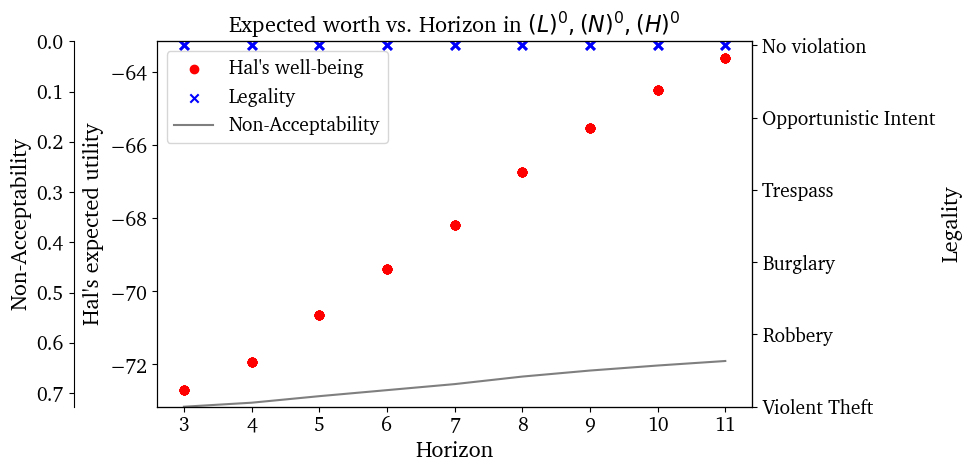

In [28]:


configName = "(L)^0, (N)^0, (H)^0"
dep_var = "Hal"
ord_con_label = "Legality"
ordinalLabels = {0: "No violation", -1: "Opportunistic Intent", -2: "Trespass", -3: "Burglary", -4: "Robbery", -5: "Violent Theft"}

df_ = df.copy()
df_ = df_[df_['Config_name'] == configName].copy()

# 1. FIX UNEVEN SPACING: Force the data to be numeric
df_[dep_var] = pd.to_numeric(df_[dep_var])
df_[ord_con_label] = df_[ord_con_label].str[2:]
df_[ord_con_label] = pd.to_numeric(df_[ord_con_label])
df_['Horizon'] = pd.to_numeric(df_['Horizon'])

fig, ax1 = plt.subplots(figsize=(10, 5))
plt.title(f"Expected worth vs. Horizon in {latex_config_name(configName)}")

# 2. FIX THE LEGEND: Add label="Hal's wellbeing"
ax1.scatter(df_['Horizon'], df_[dep_var], c='red', label="Hal's well-being")
ax1.set_ylabel("Hal's expected utility")
ax1.set_xlabel("Horizon")

ax2 = ax1.twinx() 
ax2.scatter(df_['Horizon'], df_[ord_con_label], c='blue', marker='x', label=ord_con_label)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.set_ylabel(ord_con_label)

min_nec = df_[ord_con_label].min()
max_nec = df_[ord_con_label].max()
tick_positions = np.linspace(min_nec, max_nec, 4) 
ax2.set_yticks(list(ordinalLabels.keys()))
ax2.set_yticklabels(list(ordinalLabels.values()))


ax3 = ax1.twinx()
ax3.yaxis.set_ticks_position('left')
ax3.yaxis.set_label_position('left')
ax3.spines['left'].set_position(('outward', 60))
ax3.spines['left'].set_visible(True)

ax3.set_ylabel('Non-Acceptability')
ax3.set_ylim(max(df_['Min_non_accept']),0)
ax3.plot(df_['Horizon'], df_['Min_non_accept'], c=[0,0,0,0.5], label='Non-Acceptability')


# Generate the legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles3, labels3 = ax3.get_legend_handles_labels()
ax2.legend(handles1 + handles2 + handles3, labels1 + labels2 + labels3, loc='upper left')

fig.tight_layout()
plt.show()

TypeError: expected non-empty vector for x

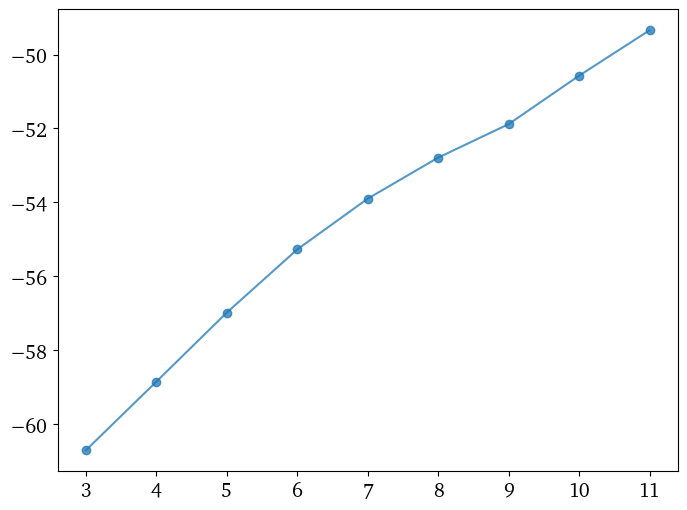

In [ ]:
configs_to_show = ["(H)^0",
                        "(L)^0, (H)^1",
                        "(N)^0, (H)^1",
                        "(L)^0, (N)^0, (H)^1",
                        "(L)^0, (N)^0, (H)^0"]
QuickPlotGraph(df, configs_to_show, 
               independent_var="Horizon", 
               dependent_var="Hal", 
               dep_label="Hal's expected wellbeing", 
               title="Hal's expected wellbeing vs. Horizon", 
               regression=True)

## Runtime growth and timing components

The total-time graph first averages **Total_time** by configuration and horizon.

**average_durations** then averages every field in **ExperimentRunner.time_columns**—Total, Heuristic, Plan, Solution extraction, and MEHR—for selected configurations and horizons. Component colour identifies the timing stage; line style and marker identify the configuration.

Later cells recreate **df** from **er.data**, so rerun the earlier cleaning cell before returning to plots that expect shortened configuration labels.


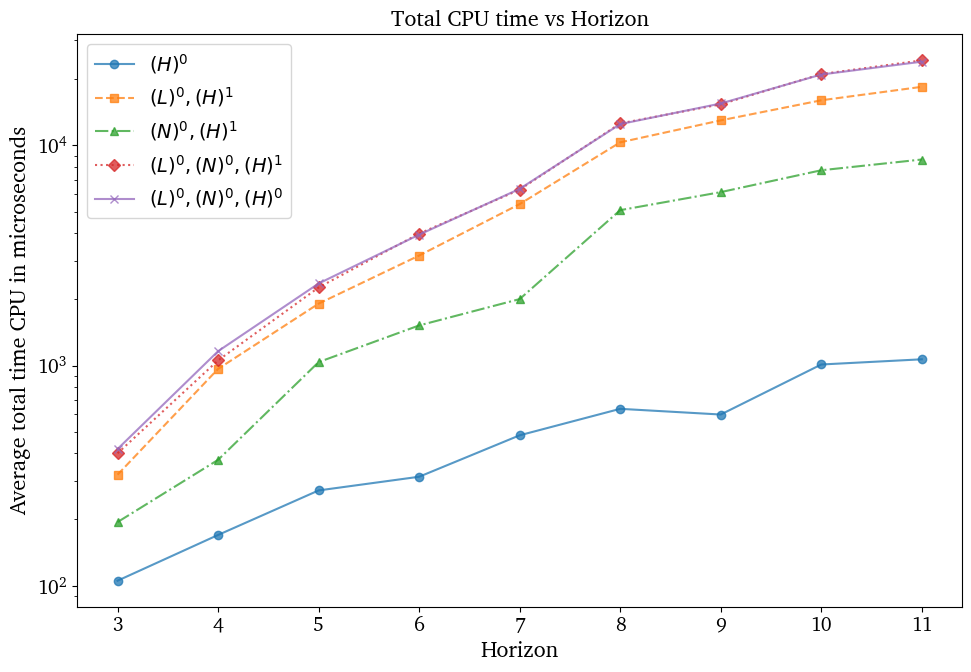

In [31]:
plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

dep_var = "Total_time"

# Make a copy of the whole dataframe, because you want every Config_name
df_ = df.copy()

# Ensure numeric values
df_[dep_var] = pd.to_numeric(df_[dep_var])
df_["Horizon"] = pd.to_numeric(df_["Horizon"])

fig, ax = plt.subplots(figsize=(10, 7))

linestyles = ["-", "--", "-.", ":"]
markers = ["o", "s", "^", "D", "x", "*"]

configs_to_show = ["(H)^0",
                   "(L)^0, (H)^1",
                   "(N)^0, (H)^1",
                   "(L)^0, (N)^0, (H)^1",
                   "(L)^0, (N)^0, (H)^0"]
df_ = df_.groupby(['Config_name', 'Horizon'])["Total_time"].mean().reset_index()

for i, config_name in enumerate(configs_to_show):
    group = df_[df_["Config_name"] == config_name].sort_values("Horizon")
    ax.plot(
        group["Horizon"],
        group[dep_var],
        marker=markers[i  % len(markers)],
        label=latex_config_name(config_name),
        alpha=0.75,
        linewidth=1.5,
        linestyle=linestyles[i % len(linestyles)]
    )

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title("Total CPU time vs Horizon")
ax.set_xlabel("Horizon")
ax.set_ylabel(f"Average total time CPU in microseconds")
ax.set_yscale('log')  # Set the y-axis to logarithmic scale

ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


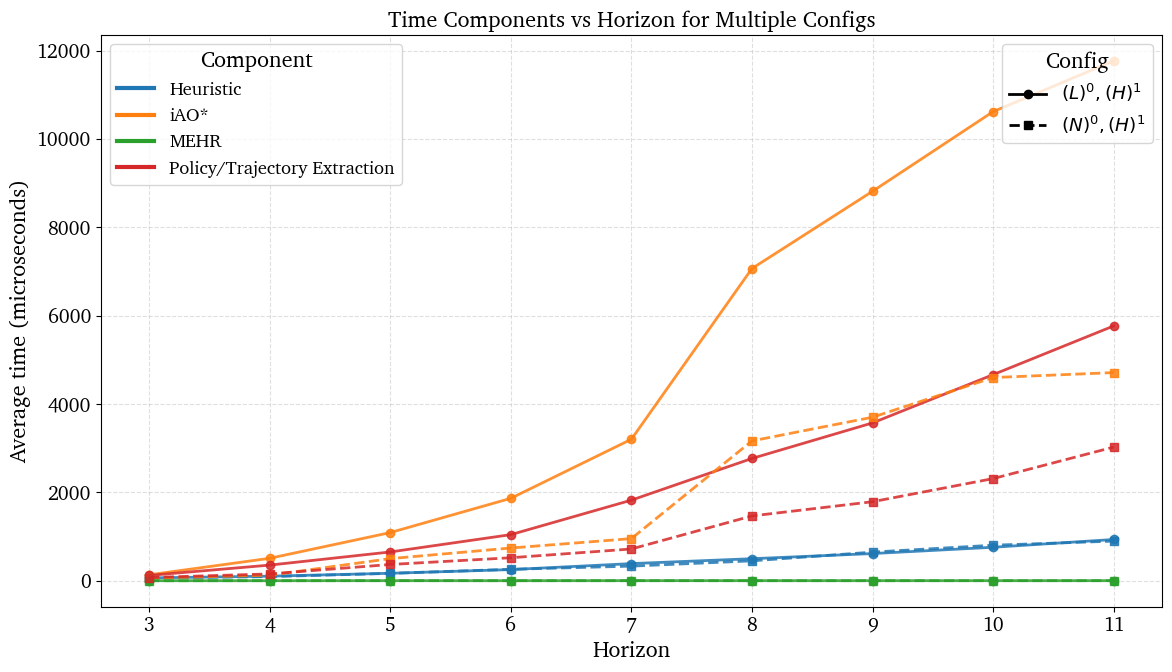

,Config_name,Horizon,Total_time,Heuristic_time,Plan_time,Mehr_time,Sol_time
0,"(L)^0, (H)^1",3,319.6,64.3,134.1,1.0,120.2
1,"(L)^0, (H)^1",4,966.2,103.6,507.7,1.0,353.9
2,"(L)^0, (H)^1",5,1912.4,169.0,1089.9,2.0,651.5
3,"(L)^0, (H)^1",6,3162.9,252.6,1865.5,1.3,1043.5
4,"(L)^0, (H)^1",7,5417.0,388.0,3202.4,2.2,1824.4
5,"(L)^0, (H)^1",8,10336.8,499.2,7067.5,2.0,2768.1
6,"(L)^0, (H)^1",9,13006.0,615.4,8815.8,2.0,3572.8
7,"(L)^0, (H)^1",10,16044.8,758.1,10619.2,2.0,4665.5
8,"(L)^0, (H)^1",11,18472.9,934.1,11768.3,2.0,5768.5
9,"(N)^0, (H)^1",3,194.6,62.9,57.9,0.5,73.3


In [13]:
from matplotlib.lines import Line2D

config_names = ["(L)^0, (H)^1", "(N)^0, (H)^1"]
labels = {"Heuristic_time": "Heuristic", "Mehr_time": "MEHR", "Plan_time": "iAO*", "Sol_time": "Policy/Trajectory Extraction"}

average_durations = df[df['Config_name'].isin(config_names)].copy()
average_durations = average_durations.groupby(['Config_name', 'Horizon'])[ExperimentRunner.time_columns].mean().reset_index()
average_durations['Mehr_time'] = average_durations['Mehr_time'].replace(0, 0.0001)

cols = deepcopy(ExperimentRunner.time_columns)
cols.remove('Total_time')

plt.figure(figsize=(12, 7))

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
component_colors = {col: color_cycle[i % len(color_cycle)] for i, col in enumerate(cols)}
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'D', 'x', '*']

for cfg_idx, config in enumerate(config_names):
    config_group = average_durations[average_durations['Config_name'] == config]
    style = line_styles[cfg_idx % len(line_styles)]
    marker = markers[cfg_idx % len(markers)]
    for column in cols:
        plt.plot(
            config_group['Horizon'],
            config_group[column],
            linestyle=style,
            marker=marker,
            color=component_colors[column],
            label=f"{labels[column]} — {latex_config_name(config)}",
            alpha=0.85,
            linewidth=2,
            markersize=6,
        )

plt.title("Time Components vs Horizon for Multiple Configs")
plt.xlabel("Horizon")
plt.ylabel("Average time (microseconds)")
plt.xticks(ticks=np.arange(min(average_durations['Horizon']), max(average_durations['Horizon']) + 1, 1))

component_handles = [Line2D([0], [0], color=component_colors[col], lw=3) for col in cols]
config_handles = [Line2D([0], [0], color='black', lw=2, linestyle=line_styles[i % len(line_styles)], marker=markers[i % len(markers)]) for i in range(len(config_names))]

legend1 = plt.legend(component_handles, [labels[col] for col in cols], title='Component', loc='upper left', fontsize='small')
legend2 = plt.legend(config_handles, [latex_config_name(c) for c in config_names], title='Config', loc='upper right', fontsize='small')
plt.gca().add_artist(legend1)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
average_durations.head(100)

In [14]:

df = pd.DataFrame(er.data)
        
average_durations = df.copy()
if (not config_name is None):
    average_durations = average_durations[average_durations['Config_name']==config_name]
average_durations.head(100)


,Config_name,Conf_rep,Env_rep,Theories,Considerations,Total_time,Heuristic_time,Plan_time,Sol_time,Mehr_time,...,Iterations,Horizon,Min_non_accept,Num_of_min_non_accept,Num_of_sols,Total_Attacks,Total_reachable_policies,Hal,Legality,Necessity


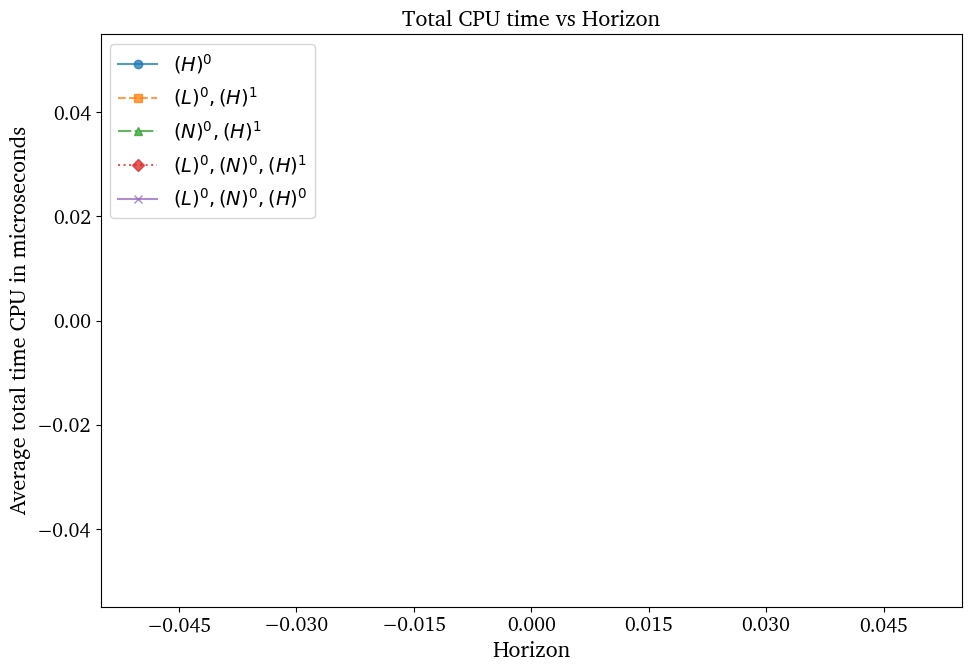

In [15]:

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

dep_var = "Total_time"

# Make a copy of the whole dataframe, because you want every Config_name
df_ = df.copy()

# Ensure numeric values
df_[dep_var] = pd.to_numeric(df_[dep_var])
df_["Horizon"] = pd.to_numeric(df_["Horizon"])

fig, ax = plt.subplots(figsize=(10, 7))

linestyles = ["-", "--", "-.", ":"]
markers = ["o", "s", "^", "D", "x", "*"]

configs_to_show = ["(H)^0",
                   "(L)^0, (H)^1",
                   "(N)^0, (H)^1",
                   "(L)^0, (N)^0, (H)^1",
                   "(L)^0, (N)^0, (H)^0"]
for i, config_name in enumerate(configs_to_show):
    group = df_[df_["Config_name"] == config_name].sort_values("Horizon")
    ax.plot(
        group["Horizon"],
        group[dep_var],
        marker=markers[i  % len(markers)],
        label=latex_config_name(config_name),
        alpha=0.75,
        linewidth=1.5,
        linestyle=linestyles[i % len(linestyles)]
    )

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title("Total CPU time vs Horizon")
ax.set_xlabel("Horizon")
ax.set_ylabel(f"Average total time CPU in microseconds")

ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

